# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2.Load Dataset

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# 3.Explore Dataset

In [3]:
df.head()

df.info()

df.describe()

df.shape

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


np.int64(0)

# 4.Data Cleaning

In [4]:
df = df.drop("Unnamed: 0", axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# 5.Exploratory Data Analysis (EDA)

### Correlation Heatmap

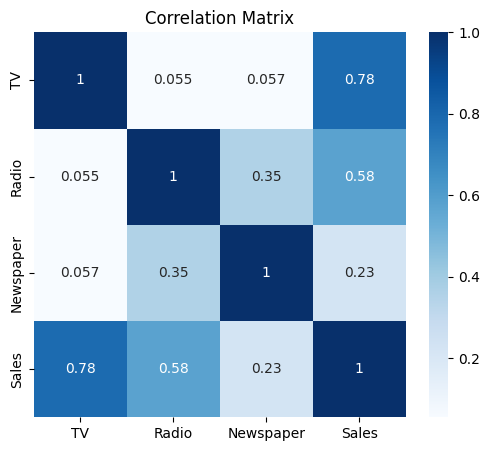

In [5]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

### Pair Plot

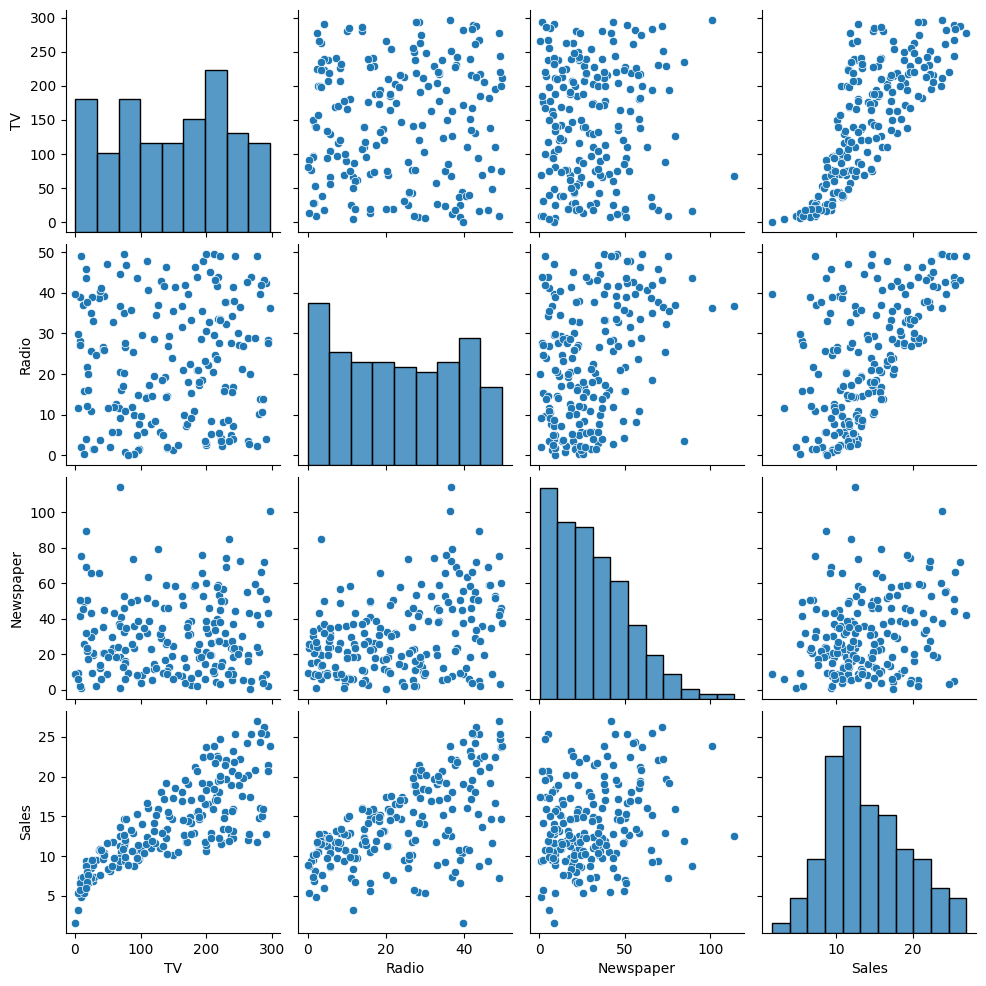

In [6]:
sns.pairplot(df)
plt.show()

### Sales Distribution

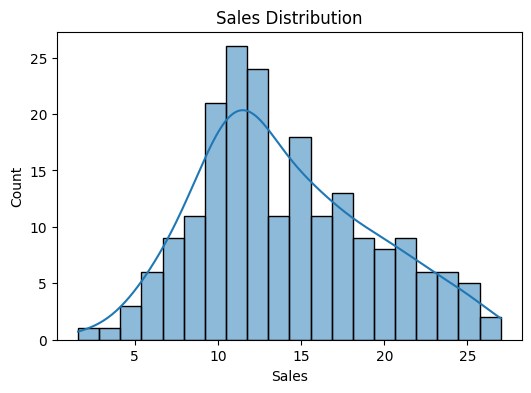

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["Sales"], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

### TV vs Sales

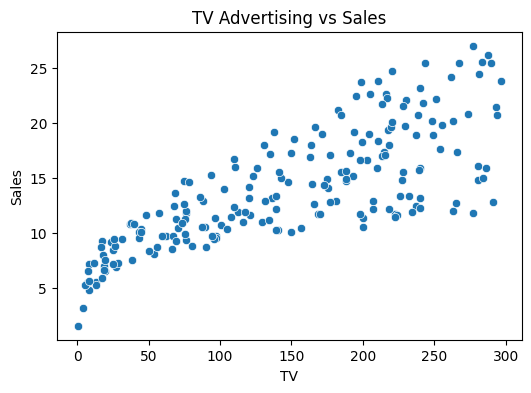

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising vs Sales")
plt.show()

### Radio vs Sales

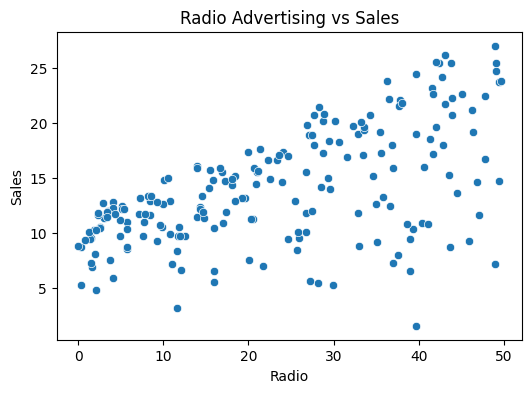

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

### Newspaper vs Sales

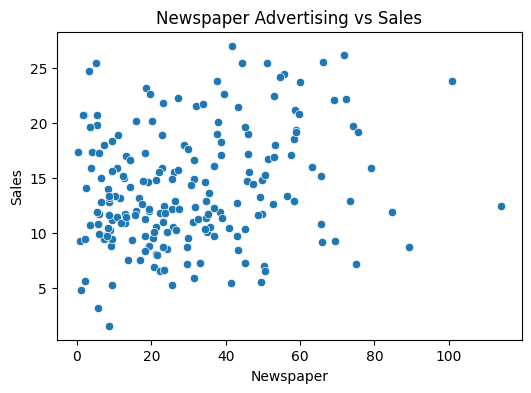

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

# 6.Feature Selection

In [11]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

# 7.Split Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8.Train Model

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 9.Predict Sales

In [14]:
y_pred = model.predict(X_test)

# 10.Evaluate Model

In [15]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE : 1.78159966153345
R2 Score : 0.899438024100912


# 11.Actual vs Predicted

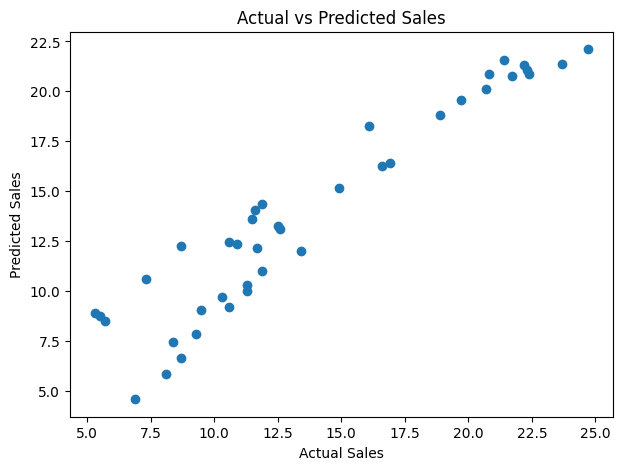

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# 12.Feature Importance

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


# 13.Predict New Sales

In [18]:
new_data = pd.DataFrame({
    "TV":[230],
    "Radio":[40],
    "Newspaper":[20]
})

prediction = model.predict(new_data)

print("Predicted Sales =", prediction[0])

Predicted Sales = 20.88988081212979


# 14.Business Insights

#### TV advertising has the strongest positive impact on sales.
#### Radio advertising also increases sales significantly.
#### Newspaper advertising has the least impact.
#### Increasing TV marketing budget is likely to improve sales.
#### Businesses should focus more on TV and Radio advertisements.

# 15. Conclusion



#### * Built a Linear Regression model to predict sales using advertising data.
#### * TV and Radio advertising showed a stronger impact on sales than Newspaper advertising.
#### * The model can help businesses improve marketing strategies and optimize advertising budgets.
